## ES-VAE with Squared Geodesic Loss (Regression)

In [1]:
import numpy as np
import pandas as pd
import random
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm

from val_test import *
from print_results import *
from functionsgpu_fast import *

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)
dtype = torch.float32

if device.type == "cuda":
    idx = device.index if device.index is not None else torch.cuda.current_device()
    print(torch.cuda.get_device_name(idx))

SEED = 42
def deterministic(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

deterministic(SEED)
# Enable (as much as possible) deterministic operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

tslen = 200

cuda:1
NVIDIA RTX A5000


## Load POMA and Participant IDs

In [2]:
# Load POMA scores and participant IDs
participant_ids = np.loadtxt('/mnt/sdb/arafat/stroke_riemann/labels_data/pids.txt')
y_poma = np.loadtxt('/mnt/sdb/arafat/stroke_riemann/labels_data/y_poma.txt')

print("y_poma shape:", y_poma.shape)
print("First 10 participant_ids:", participant_ids[:10])

y_poma shape: (155,)
First 10 participant_ids: [ 1.  2.  3.  4.  5.  6.  7.  8. 10. 11.]


## Aligned Data Loading

In [3]:
def loading(filename, tslen):
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_aligned = pickle.load(f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
        mu = pickle.load(f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
        tangent_vec_all = pickle.load(f)
    return betas_aligned, mu, tangent_vec_all

betas_aligned_all, mu_all_t, tangent_vec_all = loading('/mnt/sdb/arafat/stroke_riemann/aligned_data',tslen)
mu_all_t_tensor = torch.from_numpy(mu_all_t).to(device=device, dtype=torch.float32)

print(betas_aligned_all[0].shape, tangent_vec_all.shape, mu_all_t.shape)

(32, 3, 200) (32, 3, 200, 155) (32, 3, 200)


In [4]:
K = 32
M = 3
T = tslen
nsamples = 155

tangent_flat = tangent_vec_all.reshape((K*M*T, nsamples))
print(tangent_flat.shape)

(19200, 155)


## Nonlinear Tangent VAE

In [5]:
class NonlinearVAE(nn.Module):
    """NonlinearVAE"""
    def __init__(self, D, R, H=128, dropout=0.1):
        super().__init__()
        # Encoder layers
        self.W1 = nn.Linear(D, H, bias=False)        # input -> hidden
        self.W2_mu = nn.Linear(H, R, bias=False)     # hidden -> latent mean
        self.W2_logvar = nn.Linear(H, R)             # hidden -> latent logvar
        self.dropout = nn.Dropout(p=dropout)
                
        # Decoder layers
        self.dec1 = nn.Linear(R, 16, bias=False)
        self.dec2 = nn.Linear(16, D, bias=False)

    def encode(self, x):
        h = torch.tanh(self.W1(x))
        h = self.dropout(h)
        mu = self.W2_mu(h)
        logvar = self.W2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_recon = torch.tanh(self.dec1(z))
        x_hat = self.dec2(h_recon)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z

def esvae_loss(x_man, x_hat_man, mu, logvar, beta=1e-4):
    dist = squared_geodesic_distance(x_man, x_hat_man, K, M, T)
    recon = torch.mean(dist.sum(dim=1))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    avg_kl = kl.mean()
    return recon + beta * avg_kl, recon, avg_kl

## ES-VAE Architecture

In [6]:
class ESVAE(nn.Module):
    """rVAE: encode tangent vectors, decode to tangent, but (during
    training) compare reconstructions on the manifold via an exp map.

    - Inputs: tangent vectors (N, D) as in the VAE section.
    - Decoder: produces tangent vectors.
    - Training loss: uses expmap(mu, v_hat) vs. original manifold trajectory.
    """
    def __init__(self, base_vae, mu_shape, expmap):
        super().__init__()
        self.vae = base_vae
        # mean shape, used for exponential map when mapping back to manifold
        self.register_buffer("mu_shape", mu_shape)
        self.expmap = expmap

    def forward(self, x):
        """Forward on tangent vectors.

        x : (N, D) tangent vectors
        Returns
        -------
        x_man_hat : (N, D) manifold trajectory flattened (via expmap)
        mu_z, logvar, z, v_hat : usual VAE outputs (in tangent space)
        """
        v_hat, mu_z, logvar, z = self.vae(x)   # tangent reconstruction

        # Map reconstructed tangent field back to the manifold
        B = v_hat.shape[0]
        v_hat_reshaped = v_hat.view(B, K, M, T)
        mu = self.mu_shape.view(K, M, T)
        x_recon_man = self.expmap(mu, v_hat_reshaped)   # (B, K, M, T)
        x_recon_man = x_recon_man.view(B, -1)

        return x_recon_man, mu_z, logvar, z, v_hat

## Getting Orginal Trajectories on Manifold

In [7]:
betas = np.array(betas_aligned_all)
print(betas.shape)   # (155, 32, 3, 200)

N, K, M, T = betas.shape   # correct order

# Shape mean as before (kept for potential manifold utilities)
mu_shape = torch.from_numpy(
    mu_all_t.reshape(-1).astype(np.float32)
).to(device)

print("mu_shape:", mu_shape.shape)      # should be (19200,)

(155, 32, 3, 200)
mu_shape: torch.Size([19200])


## Training Function for Each Fold

In [8]:
def train_esvae_fold(X_tan_train, X_man_train, K, M, T, 
                            R=10, num_epochs=2000, lr=1e-3, betakl=2**(-3), 
                            verbose=False, seed=42):
    """Train a fresh KendallRVAE on a training subset only.

    X_tan_train : (N_train, D) tangent vectors
    X_man_train : (N_train, K*M*T) manifold trajectories (flattened)
    seed : random seed for model initialization
    """
    # Set seeds before model initialization for reproducibility
    deterministic(seed)
    
    D = X_tan_train.shape[1]

    base_vae_fold = NonlinearVAE(D, R).to(device=device, dtype=dtype)
    model_fold = ESVAE(base_vae_fold, mu_shape, exp_gpu_batch).to(device=device, dtype=dtype)
    opt_fold = torch.optim.Adam(model_fold.parameters(), lr=lr)
    
    for epoch in range(num_epochs):
        model_fold.train()
        opt_fold.zero_grad(set_to_none=True)
        x_hat_man_train, mu_train, logvar_train, z_train, v_hat_train = model_fold(X_tan_train)
        loss_train, recon_train, kl_train = esvae_loss(X_man_train, x_hat_man_train, 
                                            mu_train, logvar_train, beta=betakl)
        loss_train.backward()
        opt_fold.step()

        if verbose and (epoch % 300 == 0 or epoch == num_epochs - 1):
            print(f"[fold KT-RSV] epoch: {epoch} | train loss: {loss_train:.3f}")
            
    model_fold.eval()
    return model_fold

## ES-VAE Cross Validation

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models with random_state set for reproducibility
models = {'KNN': KNeighborsRegressor()}

# Leave-10-participants-out CV: 5 validation + 5 test (disjoint). Two rounds so every subject is validated and tested once.
n = len(y_poma)
all_results_nested = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models.keys()}
participant_ids = np.asarray(participant_ids)
all_results_validation = {name: {'targets': [], 'preds': []} for name in models.keys()}

n_folds = 30
R = 38
X_tan = torch.from_numpy(tangent_flat.T.astype(np.float32)).to(device=device, dtype=dtype)
X_man = torch.from_numpy(betas.reshape(betas.shape[0], -1).astype(np.float32)).to(device=device, dtype=dtype)

for k in tqdm(range(n_folds), total=n_folds, desc='ES-VAE folds'):
    validation_pids_list, test_pids_list = val_test(participant_ids, k)
    validation_pids = set(validation_pids_list)
    test_pids = set(test_pids_list)
    train_pids = set(participant_ids) - validation_pids - test_pids

    train_idx = np.array([j for j in range(n) if participant_ids[j] in train_pids])
    test_idx = np.array([j for j in range(n) if participant_ids[j] in test_pids])
    validation_idx = np.array([j for j in range(n) if participant_ids[j] in validation_pids])

    if len(train_idx) == 0 or len(test_idx) == 0 or len(validation_idx) == 0:
        continue

    fold_seed = SEED + k
    deterministic(fold_seed)

    # Slice tangent and manifold data for this fold
    X_tan_train = X_tan[train_idx]
    X_man_train = X_man[train_idx]

    X_tan_val = X_tan[validation_idx]
    X_man_val = X_man[validation_idx]

    # Train fold-specific ESVAE on train participants only
    model_fold = train_esvae_fold(X_tan_train, X_man_train, K, M, T,
                                         R=R, num_epochs=25, lr=1e-3, seed=fold_seed)

    # Extract latent means (mu) for train, validation, and test using the fold-specific encoder
    with torch.no_grad():
        mu_train_fold, _ = model_fold.vae.encode(X_tan_train)
        mu_validation_fold, _ = model_fold.vae.encode(X_tan[validation_idx])
        mu_test_fold, _ = model_fold.vae.encode(X_tan[test_idx])

    Z_train_fold = mu_train_fold.detach().cpu().numpy()
    Z_validation_fold = mu_validation_fold.detach().cpu().numpy()
    Z_test_fold = mu_test_fold.detach().cpu().numpy()

    y_train_fold = y_poma[train_idx]
    y_validation_fold = y_poma[validation_idx]
    y_test_fold = y_poma[test_idx]

    # Train and evaluate each regressor on this fold's latents
    for name, model_reg in models.items():
        # fresh instance with same random_state
        m = type(model_reg)(**model_reg.get_params())
        m.fit(Z_train_fold, y_train_fold)

        # Validation predictions
        validation_preds = m.predict(Z_validation_fold)
        
        # Test predictions
        test_preds = m.predict(Z_test_fold)

        # Store validation results for per-fold reporting
        all_results_validation[name]['targets'].extend(y_validation_fold.tolist())
        all_results_validation[name]['preds'].extend(validation_preds.tolist())

        # Store test results for global metrics
        all_results_nested[name]['targets'].extend(y_test_fold.tolist())
        all_results_nested[name]['preds'].extend(test_preds.tolist())
        all_results_nested[name]['subjects'].extend(participant_ids[test_idx].tolist())

        # Per-fold validation metrics (printed)
        mae_validation_fold = mean_absolute_error(y_validation_fold, validation_preds)
        rmse_validation_fold = np.sqrt(mean_squared_error(y_validation_fold, validation_preds))
        r2_validation_fold = r2_score(y_validation_fold, validation_preds)

        print(
            f"Fold {k + 1:02d} | {name} | Validation: "
            f"MAE={mae_validation_fold:.3f}, RMSE={rmse_validation_fold:.3f}, R2={r2_validation_fold:.3f}"
        )

results_nested_df = print_results_regression(all_results_validation, all_results_nested, models)
results_nested_df

ES-VAE folds:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 01 | KNN | Validation: MAE=2.000, RMSE=3.142, R2=0.589
Fold 02 | KNN | Validation: MAE=4.280, RMSE=6.958, R2=-3.034
Fold 03 | KNN | Validation: MAE=4.120, RMSE=4.669, R2=-0.060
Fold 04 | KNN | Validation: MAE=4.560, RMSE=5.498, R2=0.393
Fold 05 | KNN | Validation: MAE=2.720, RMSE=3.593, R2=0.577
Fold 06 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 07 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 08 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 09 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 10 | KNN | Validation: MAE=0.040, RMSE=0.089, R2=0.000
Fold 11 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 12 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 13 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 14 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 15 | KNN | Validation: MAE=0.000, RMSE=0.000, R2=1.000
Fold 16 | KNN | Validation: MAE=4.280, RMSE=4.769, R2=-0.081
Fold 17 | KNN | Validation: MAE=4.600

,MAE,RMSE,R2,Pearson r,Pearson p
KNN,1.246452,2.81764,0.740034,0.861915,5.565299e-47


In [10]:
from ci import *

ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci(
    all_results_nested[name]['targets'],
    all_results_nested[name]['preds'],
    all_results_nested[name]['subjects'])

pd.DataFrame(ci_results['KNN'])

,MAE,RMSE,R2,Pearson r
mean,1.246452,2.81764,0.740034,0.861915
ci,"[0.941, 1.537]","[2.292, 3.212]","[0.659, 0.817]","[0.823, 0.906]"


In [11]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "figure.titlesize": 16,
})


In [12]:
yt = all_results_nested[name]['targets']
yp = all_results_nested[name]['preds']

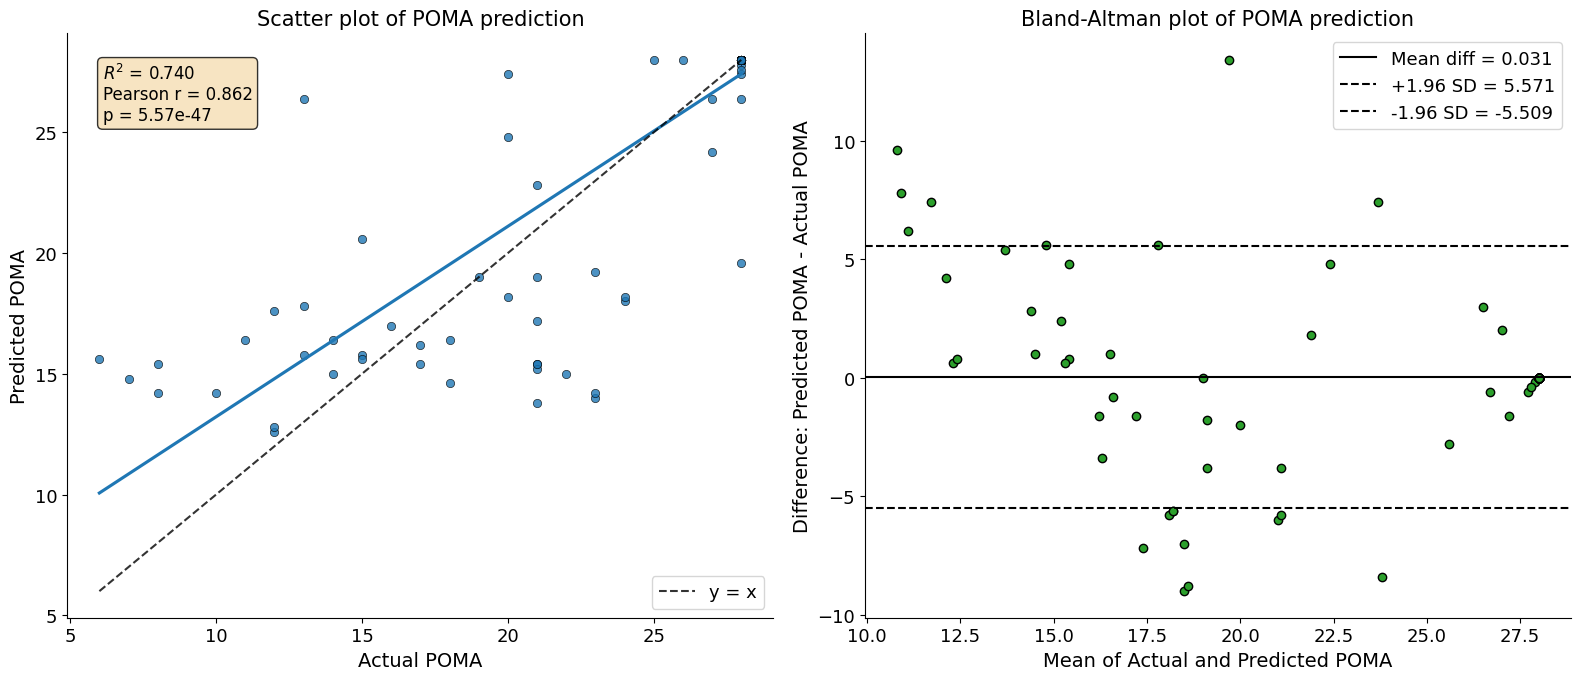

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score
from scipy.stats import pearsonr


yt = np.asarray(yt)
yp = np.asarray(yp)

r2 = r2_score(yt, yp)
r_pearson, p_value = pearsonr(yt, yp)

mean_vals = (yt + yp) / 2
diff_vals = yp - yt

mean_diff = np.mean(diff_vals)
std_diff = np.std(diff_vals, ddof=1)

loa_upper = mean_diff + 1.96 * std_diff
loa_lower = mean_diff - 1.96 * std_diff

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]

sns.regplot(
    x=yt,
    y=yp,
    ax=ax,
    scatter_kws={"edgecolor": "k", "linewidths": 0.5},
    color="tab:blue",
    ci=None,
)

lims = [
    min(yt.min(), yp.min()),
    max(yt.max(), yp.max()),
]

ax.plot(lims, lims, "k--", alpha=0.8, label="y = x")

ax.set_xlabel("Actual POMA")
ax.set_ylabel("Predicted POMA")
ax.set_title("Scatter plot of POMA prediction")
ax.legend(loc="lower right")

textstr = (
    f"$R^2$ = {r2:.3f}\n"
    f"Pearson r = {r_pearson:.3f}\n"
    f"p = {p_value:.2e}"
)

ax.text(
    0.05,
    0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.8},
)


ax = axes[1]

ax.scatter(
    mean_vals,
    diff_vals,
    edgecolor="k",
    color="tab:green",
)

ba_lines = [
    (mean_diff, "-", f"Mean diff = {mean_diff:.3f}"),
    (loa_upper, "--", f"+1.96 SD = {loa_upper:.3f}"),
    (loa_lower, "--", f"-1.96 SD = {loa_lower:.3f}"),
]

for y, linestyle, label in ba_lines:
    ax.axhline(
        y,
        color="k",
        linestyle=linestyle,
        label=label,
    )

ax.set_xlabel("Mean of Actual and Predicted POMA")
ax.set_ylabel("Difference: Predicted POMA - Actual POMA")
ax.set_title("Bland-Altman plot of POMA prediction")
ax.legend(loc="upper right")

sns.despine()
plt.tight_layout()

# plt.savefig("result_figures/KTRSV_KNN_combined.png", dpi=300, bbox_inches="tight")
# plt.savefig("result_figures/KTRSV_KNN_combined.eps", bbox_inches="tight")

plt.show()

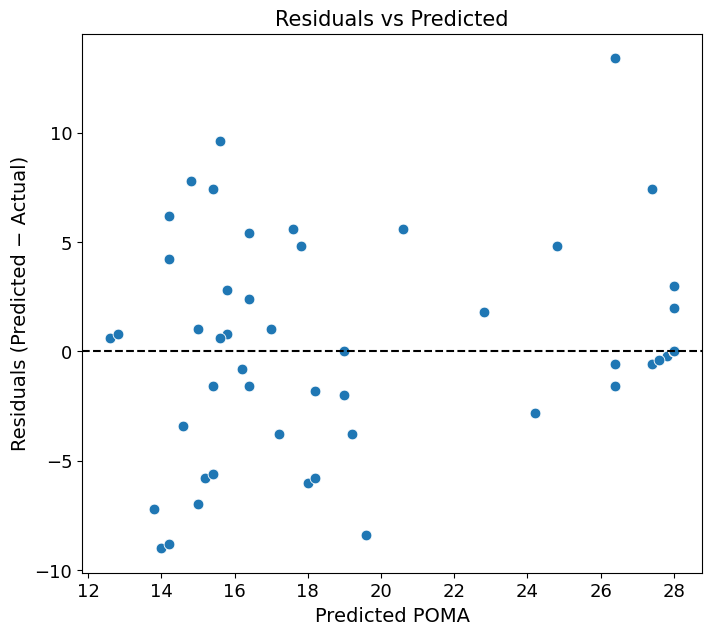

In [14]:
residuals = yp - yt

plt.figure(figsize=(8,7))
sns.scatterplot(x=yp, y=residuals, s=60)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Predicted POMA")
plt.ylabel("Residuals (Predicted − Actual)")
plt.title("Residuals vs Predicted")
# plt.savefig('result_figures/residuals_vs_predicted.png', dpi=300, bbox_inches='tight')

plt.show()

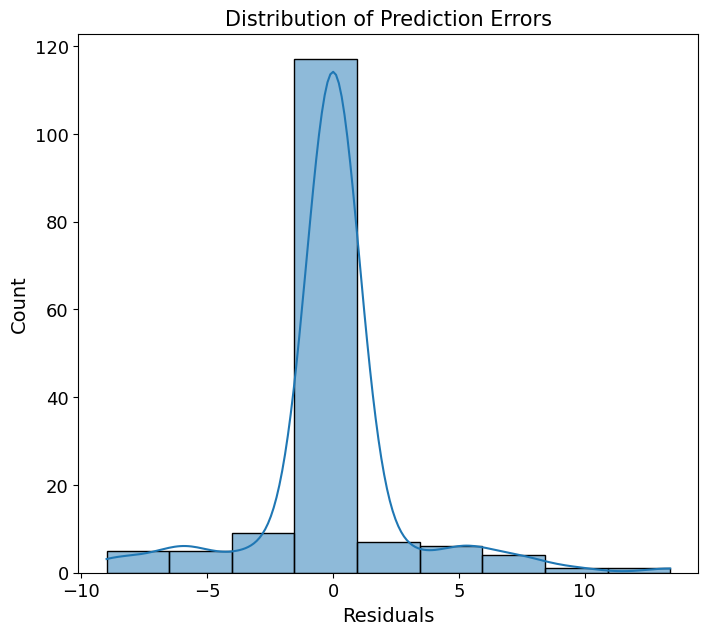

In [15]:
plt.figure(figsize=(8,7))
sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Distribution of Prediction Errors")

plt.show()

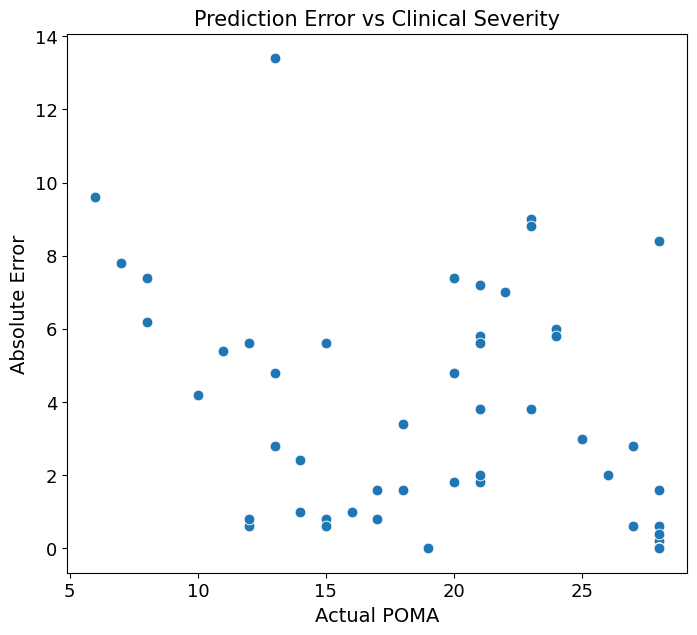

In [16]:
abs_error = np.abs(yp - yt)

plt.figure(figsize=(8,7))
sns.scatterplot(x=yt, y=abs_error, s=60)

plt.xlabel("Actual POMA")
plt.ylabel("Absolute Error")
plt.title("Prediction Error vs Clinical Severity")
# plt.savefig('result_figures/Error_Severity.png', dpi=300, bbox_inches='tight')

plt.show()